# 03 - Mô hình Dự báo Doanh thu (Sales Forecasting) - Datathon 2026

**Mục tiêu:** Dự báo `Revenue` và `COGS` cho giai đoạn từ 01/01/2023 đến 01/07/2024.

**Ràng buộc:** 

1. Không dùng dữ liệu ngoài.

2. Đảm bảo tính tái lập (Random Seed).

3. Khả năng giải thích mô hình (SHAP values).

## 1 — Imports & Config

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

d:\Documents\GitHub\Datathon\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2 — Load & Inspect Data

In [2]:
DATA_DIR = 'dataset/'

# Đọc dữ liệu và parse cột Date
train = pd.read_csv(DATA_DIR + 'sales.csv', parse_dates=['Date'])
test = pd.read_csv(DATA_DIR + 'sample_submission.csv', parse_dates=['Date'])

# Sắp xếp dữ liệu huấn luyện theo trục thời gian một cách nghiêm ngặt
train = train.sort_values('Date').reset_index(drop=True)

print(f"Kích thước tập Train: {train.shape}")
print(f"Giai đoạn Train: {train['Date'].min().date()} -> {train['Date'].max().date()}")
print(f"Kích thước tập Test: {test.shape}")
print(f"Giai đoạn Test: {test['Date'].min().date()} -> {test['Date'].max().date()}")

Kích thước tập Train: (3833, 3)
Giai đoạn Train: 2012-07-04 -> 2022-12-31
Kích thước tập Test: (548, 3)
Giai đoạn Test: 2023-01-01 -> 2024-07-01


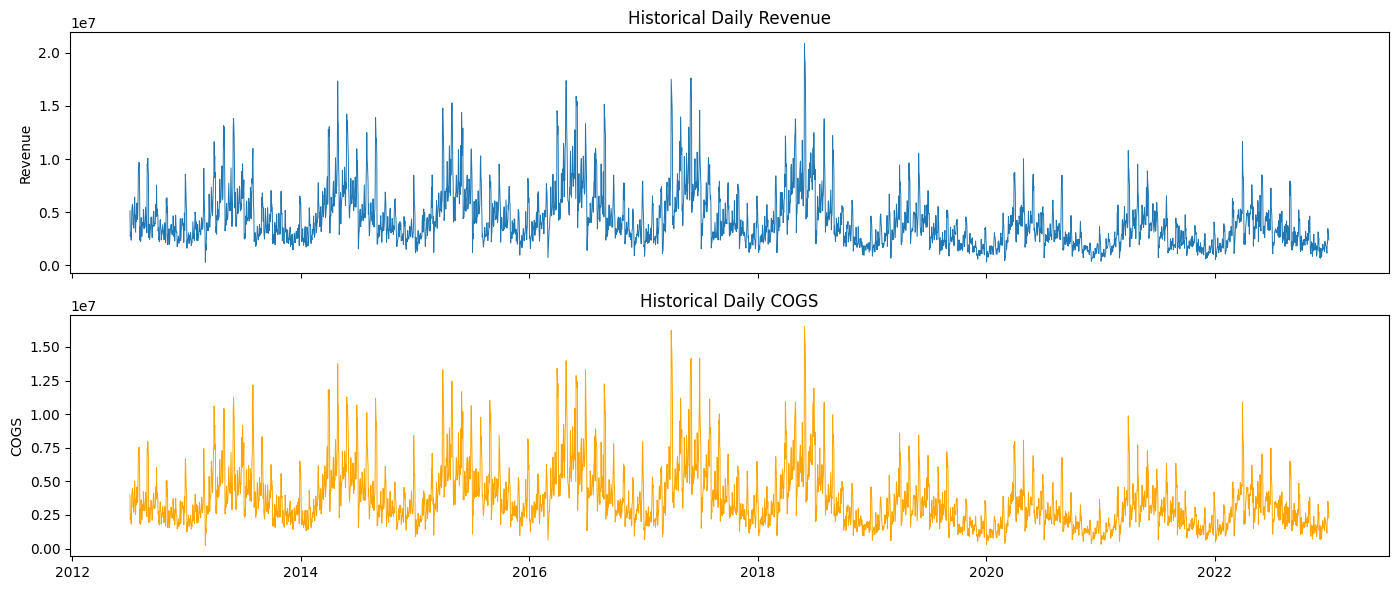

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(train['Date'], train['Revenue'], lw=0.7)
axes[0].set_title('Historical Daily Revenue'); axes[0].set_ylabel('Revenue')
axes[1].plot(train['Date'], train['COGS'], lw=0.7, color='orange')
axes[1].set_title('Historical Daily COGS'); axes[1].set_ylabel('COGS')
plt.tight_layout()
plt.show()

## 3 — Feature Engineering

In [4]:
def create_time_features(df):
    df = df.copy()
    # Các đặc trưng cơ bản
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Day'] = df['Date'].dt.day
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['DayOfYear'] = df['Date'].dt.dayofyear
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['Quarter'] = df['Date'].dt.quarter
    
    # Cờ trạng thái (Flags)
    df['Is_Weekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)
    df['Is_Month_Start'] = df['Date'].dt.is_month_start.astype(int)
    df['Is_Month_End'] = df['Date'].dt.is_month_end.astype(int)
    
    # Mùa lễ hội (Quý 4)
    df['Is_Q4_Holiday'] = df['Month'].isin([10, 11, 12]).astype(int)
    
    # Đặc trưng chu kỳ (Cyclical features)
    df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12.0)
    df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12.0)
    
    return df

# Áp dụng hàm Feature Engineering
train_feat = create_time_features(train)
test_feat = create_time_features(test)

# Định nghĩa các biến độc lập (X) và phụ thuộc (y)
features = ['Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'WeekOfYear', 
            'Quarter', 'Is_Weekend', 'Is_Month_Start', 'Is_Month_End', 
            'Is_Q4_Holiday', 'Month_Sin', 'Month_Cos']

X = train_feat[features]
y_rev = train_feat['Revenue']
y_cogs = train_feat['COGS']

X_test = test_feat[features]

## 4 - Đánh giá Mô hình (Time Series Cross-Validation)

In [5]:
# Cài đặt K-Fold thuận chiều thời gian
tscv = TimeSeriesSplit(n_splits=5)

def evaluate_xgboost(X, y, target_name="Revenue"):
    maes, rmses, r2s = [], [], []
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Khởi tạo XGBoost Regressor
        model = xgb.XGBRegressor(
            n_estimators=500, 
            learning_rate=0.03, 
            max_depth=6, 
            subsample=0.8, 
            colsample_bytree=0.8, 
            random_state=42
        )
        
        # Huấn luyện mô hình
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        preds = model.predict(X_val)
        
        # Tính toán metric
        maes.append(mean_absolute_error(y_val, preds))
        rmses.append(np.sqrt(mean_squared_error(y_val, preds)))
        r2s.append(r2_score(y_val, preds))
        
    print(f"--- Đánh giá Cross-Validation cho mục tiêu: {target_name} ---")
    print(f"MAE Trung bình : {np.mean(maes):.2f}")
    print(f"RMSE Trung bình: {np.mean(rmses):.2f}")
    print(f"R2 Trung bình  : {np.mean(r2s):.4f}\n")

# Chạy đánh giá
evaluate_xgboost(X, y_rev, "Revenue")
evaluate_xgboost(X, y_cogs, "COGS")

--- Đánh giá Cross-Validation cho mục tiêu: Revenue ---
MAE Trung bình : 1017640.07
RMSE Trung bình: 1411912.22
R2 Trung bình  : 0.6277

--- Đánh giá Cross-Validation cho mục tiêu: COGS ---
MAE Trung bình : 833527.86
RMSE Trung bình: 1144917.63
R2 Trung bình  : 0.6578



## 5 - Huấn luyện toàn bộ và Dự báo (Inference)

In [6]:
print("Đang huấn luyện Final Model cho Revenue...")
model_rev = xgb.XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=6, 
                             subsample=0.8, colsample_bytree=0.8, random_state=42)
model_rev.fit(X, y_rev)
preds_rev = model_rev.predict(X_test)

print("Đang huấn luyện Final Model cho COGS...")
model_cogs = xgb.XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=6, 
                              subsample=0.8, colsample_bytree=0.8, random_state=42)
model_cogs.fit(X, y_cogs)
preds_cogs = model_cogs.predict(X_test)

# Đảm bảo không có dự báo âm (revenue và cogs luôn >= 0)
test['Revenue'] = np.maximum(0, preds_rev)
test['COGS'] = np.maximum(0, preds_cogs)

# Định dạng lại chuỗi ngày tháng chuẩn YYYY-MM-DD
test['Date'] = test['Date'].dt.strftime('%Y-%m-%d')

# Xuất file
submission = test[['Date', 'Revenue', 'COGS']]
submission.to_csv('submission.csv', index=False)
print("Hoàn tất! Đã xuất file submission.csv sẵn sàng nộp lên Kaggle.")
submission.head()

Đang huấn luyện Final Model cho Revenue...
Đang huấn luyện Final Model cho COGS...
Hoàn tất! Đã xuất file submission.csv sẵn sàng nộp lên Kaggle.


,Date,Revenue,COGS
0,2023-01-01,2.693126e+06,2.863520e+06
1,2023-01-02,1.437820e+06,1.566503e+06
2,2023-01-03,9.843860e+05,9.082135e+05
3,2023-01-04,8.445224e+05,6.961662e+05
4,2023-01-05,7.673942e+05,6.675223e+05


## 6 - Khả năng giải thích (Explainable AI với SHAP)

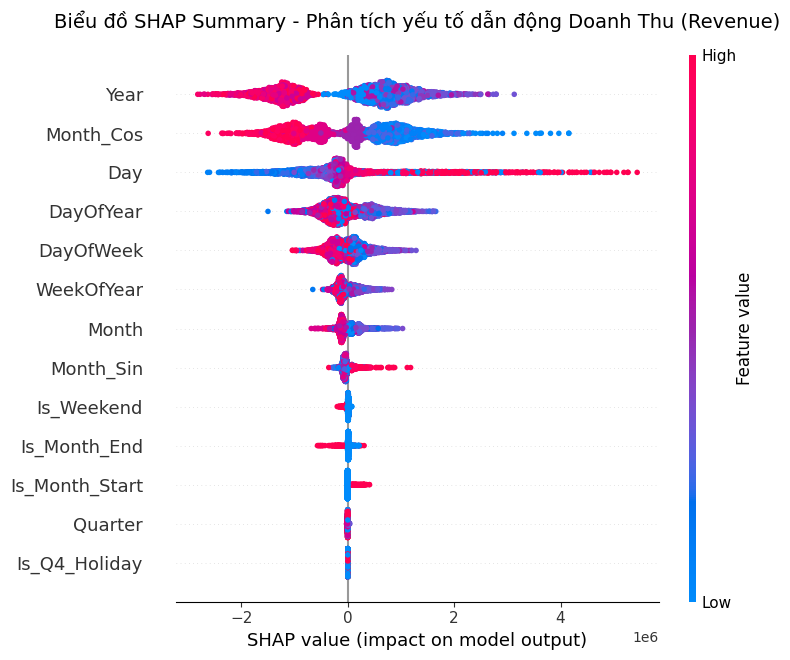

Đã xuất biểu đồ giải thích mô hình vào thư mục documentation/shap_revenue_drivers.png


In [ ]:
# Cài đặt explainer của SHAP
explainer = shap.TreeExplainer(model_rev)

# Tính toán SHAP values trên tập X (để tối ưu thời gian, có thể lấy sample 5000 dòng nếu máy yếu)
# sample_X = X.sample(5000, random_state=42) 
# shap_values = explainer.shap_values(sample_X)

shap_values = explainer.shap_values(X)

# Trực quan hoá SHAP Summary Plot
plt.figure(figsize=(12, 8))
plt.title("Biểu đồ SHAP Summary - Phân tích yếu tố dẫn động Doanh Thu (Revenue)", fontsize=14, pad=20)
shap.summary_plot(shap_values, X, show=False)

plt.tight_layout()
plt.show()

print("Đã xuất biểu đồ giải thích mô hình vào thư mục documentation/shap_revenue_drivers.png")